In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV


In [ ]:
import pandas as pd
import numpy as np
data=pd.read_csv('./cumulative.csv')
col_names_to_keep = ['koi_pdisposition','koi_period','koi_duration','koi_teq','koi_prad','koi_srad','ra','dec','koi_steff','koi_slogg']
data = data[col_names_to_keep]
print(data.head())


  koi_pdisposition  koi_period  koi_duration  koi_teq  koi_prad  koi_srad  \
0        CANDIDATE    9.488036       2.95750    793.0      2.26     0.927   
1        CANDIDATE   54.418383       4.50700    443.0      2.83     0.927   
2   FALSE POSITIVE   19.899140       1.78220    638.0     14.60     0.868   
3   FALSE POSITIVE    1.736952       2.40641   1395.0     33.46     0.791   
4        CANDIDATE    2.525592       1.65450   1406.0      2.75     1.046   

          ra        dec  koi_steff  koi_slogg  
0  291.93423  48.141651     5455.0      4.467  
1  291.93423  48.141651     5455.0      4.467  
2  297.00482  48.134129     5853.0      4.544  
3  285.53461  48.285210     5805.0      4.564  
4  288.75488  48.226200     6031.0      4.438  


In [ ]:
null_count = data.isnull().sum().sum()

print(f"Total number of null entries: {null_count}")

Total number of null entries: 1815


In [ ]:
print(f"Total number of null entries: {null_count}")
for column in data.columns:
    if data[column].dtype in ['float64', 'int64']:  # Only apply to numeric columns
        mean_value = data[column].mean()
        data[column].fillna(mean_value, inplace=True)

Total number of null entries: 1815


/tmp/ipython-input-2131067157.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[column].fillna(mean_value, inplace=True)


In [ ]:

print(np.unique(data['koi_pdisposition']))


['CANDIDATE' 'FALSE POSITIVE']


In [ ]:
data['koi_pdisposition'] = data['koi_pdisposition'].replace({'FALSE POSITIVE': 0, 'CANDIDATE': 1})

/tmp/ipython-input-4178108897.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['koi_pdisposition'] = data['koi_pdisposition'].replace({'FALSE POSITIVE': 0, 'CANDIDATE': 1})


In [ ]:
print(data.head())

   koi_pdisposition  koi_period  koi_duration  koi_teq  koi_prad  koi_srad  \
0                 1    9.488036       2.95750    793.0      2.26     0.927   
1                 1   54.418383       4.50700    443.0      2.83     0.927   
2                 0   19.899140       1.78220    638.0     14.60     0.868   
3                 0    1.736952       2.40641   1395.0     33.46     0.791   
4                 1    2.525592       1.65450   1406.0      2.75     1.046   

          ra        dec  koi_steff  koi_slogg  
0  291.93423  48.141651     5455.0      4.467  
1  291.93423  48.141651     5455.0      4.467  
2  297.00482  48.134129     5853.0      4.544  
3  285.53461  48.285210     5805.0      4.564  
4  288.75488  48.226200     6031.0      4.438  


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt




In [ ]:
import matplotlib.pyplot as plt

In [ ]:
print("Columns in data:", data.columns.tolist())


Columns in data: ['koi_pdisposition', 'koi_period', 'koi_duration', 'koi_teq', 'koi_prad', 'koi_srad', 'ra', 'dec', 'koi_steff', 'koi_slogg']



x_col = data.columns[0]
y_col = data.columns[1]

plt.figure(figsize=(8, 6))
plt.scatter(data[x_col], data[y_col], alpha=0.7)

plt.title(f"Scatter Plot of {x_col} vs {y_col}")
plt.xlabel(x_col)
plt.ylabel(y_col)
plt.grid(True)
plt.show()

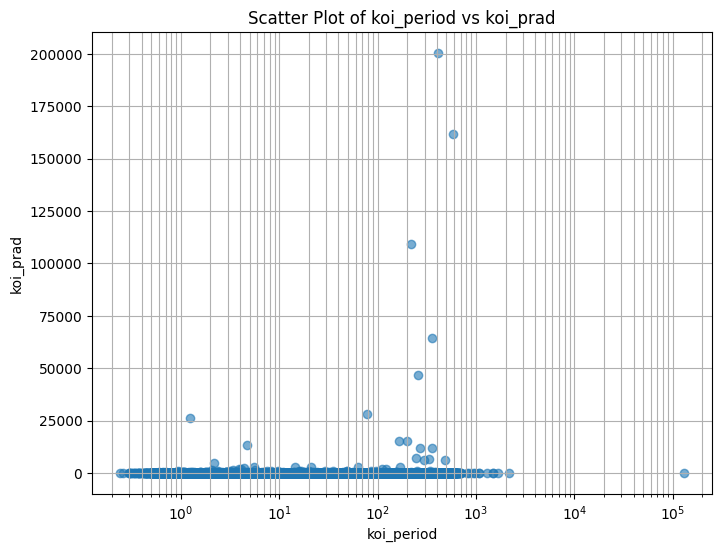

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(data["koi_period"], data["koi_prad"], alpha=0.6)
plt.xscale("log")
plt.title("Scatter Plot of koi_period vs koi_prad")
plt.xlabel("koi_period")
plt.ylabel("koi_prad")
plt.grid(True, which="both")
plt.show()

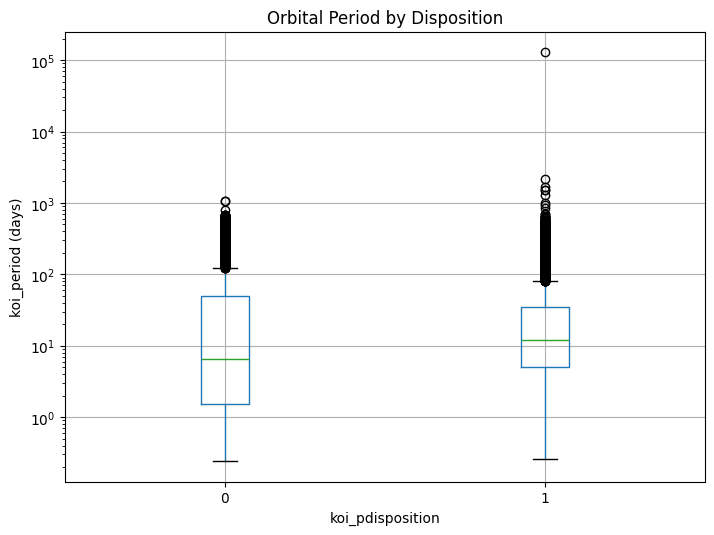

In [ ]:
data.boxplot(column="koi_period", by="koi_pdisposition", figsize=(8,6))
plt.title("Orbital Period by Disposition")
plt.suptitle("")
plt.ylabel("koi_period (days)")
plt.yscale("log")
plt.show()

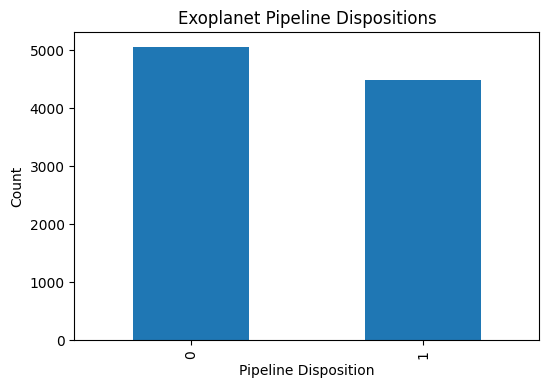

In [ ]:
data["koi_pdisposition"].value_counts().plot(kind="bar", figsize=(6,4))

plt.title("Exoplanet Pipeline Dispositions")
plt.xlabel("Pipeline Disposition")
plt.ylabel("Count")
plt.show()

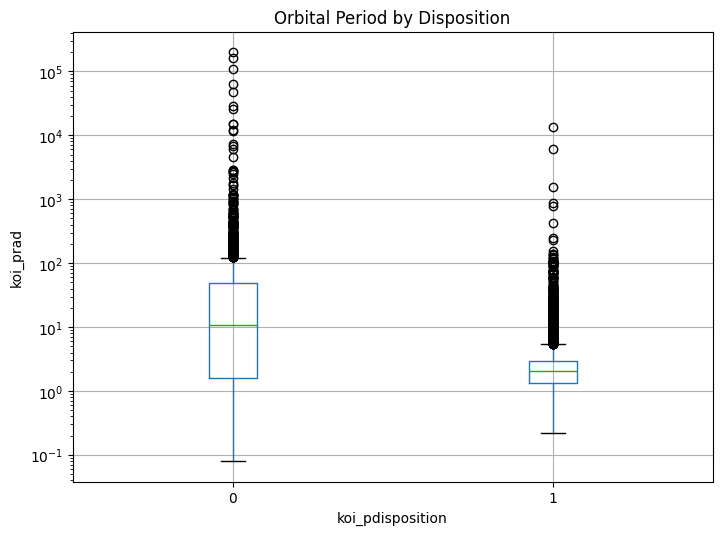

In [ ]:
data.boxplot(column="koi_prad", by="koi_pdisposition", figsize=(8,6))
plt.title("Orbital Period by Disposition")
plt.suptitle("")
plt.ylabel("koi_prad")
plt.yscale("log")
plt.show()

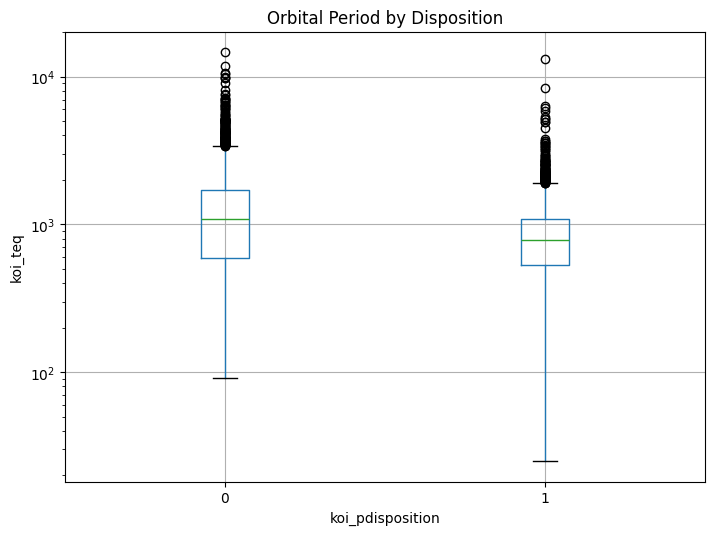

In [ ]:
data.boxplot(column="koi_teq", by="koi_pdisposition", figsize=(8,6))
plt.title("Orbital Period by Disposition")
plt.suptitle("")
plt.ylabel("koi_teq")
plt.yscale("log")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import RidgeClassifier

In [ ]:
X = data.drop('koi_pdisposition', axis=1)
y = data['koi_pdisposition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

              precision    recall  f1-score   support

           0       0.86      0.83      0.85      1019
           1       0.82      0.84      0.83       894

    accuracy                           0.84      1913
   macro avg       0.84      0.84      0.84      1913
weighted avg       0.84      0.84      0.84      1913

Accuracy: 0.8389963408259279
Cross-validation scores: [0.80188186 0.87558808 0.79665447 0.83533717 0.7207113 ]
Mean accuracy: 0.8060345751486745


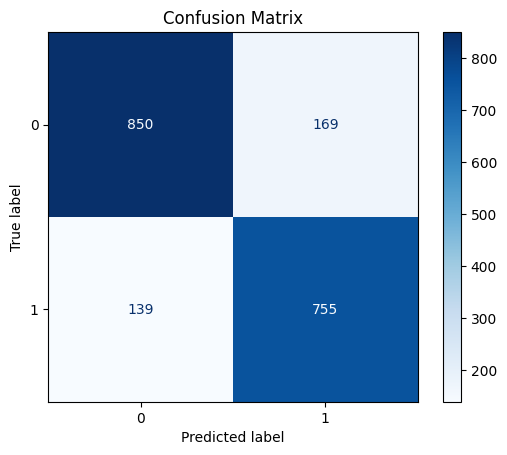

In [ ]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test,y_pred))


from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
print("Cross-validation scores:", scores)
print("Mean accuracy:", scores.mean())

# Plot the confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()

              precision    recall  f1-score   support

           0       0.69      0.63      0.66      1019
           1       0.62      0.68      0.65       894

    accuracy                           0.66      1913
   macro avg       0.66      0.66      0.66      1913
weighted avg       0.66      0.66      0.66      1913

Accuracy: 0.6555148980658652
Cross-validation scores: [0.70047047 0.70883429 0.60846837 0.64819655 0.64487448]
Mean accuracy: 0.662168831623313


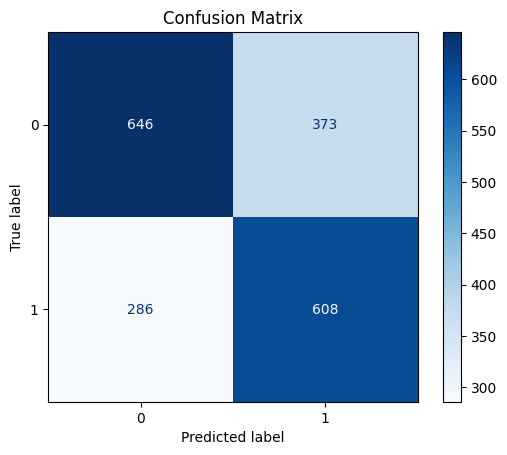

In [ ]:
model = RidgeClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test,y_pred))


from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
print("Cross-validation scores:", scores)
print("Mean accuracy:", scores.mean())

# Plot the confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()

              precision    recall  f1-score   support

           0       0.69      0.63      0.66      1019
           1       0.62      0.68      0.65       894

    accuracy                           0.66      1913
   macro avg       0.66      0.66      0.66      1913
weighted avg       0.66      0.66      0.66      1913

Accuracy: 0.6555148980658652
Cross-validation scores: [0.70047047 0.70883429 0.60846837 0.64819655 0.64487448]
Mean accuracy: 0.662168831623313


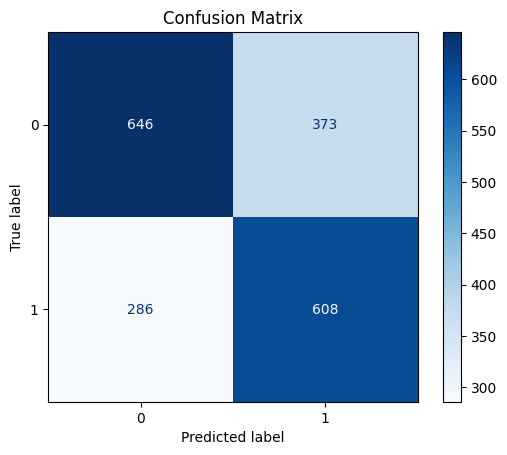

In [ ]:
model = RidgeClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test,y_pred))


from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
print("Cross-validation scores:", scores)
print("Mean accuracy:", scores.mean())

# Plot the confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()

              precision    recall  f1-score   support

           0       0.81      0.64      0.71      1019
           1       0.67      0.82      0.74       894

    accuracy                           0.73      1913
   macro avg       0.74      0.73      0.73      1913
weighted avg       0.74      0.73      0.72      1913

Accuracy: 0.7260846837428123
Cross-validation scores: [0.67067433 0.68949294 0.63826451 0.66544694 0.64748954]
Mean accuracy: 0.662273652853084


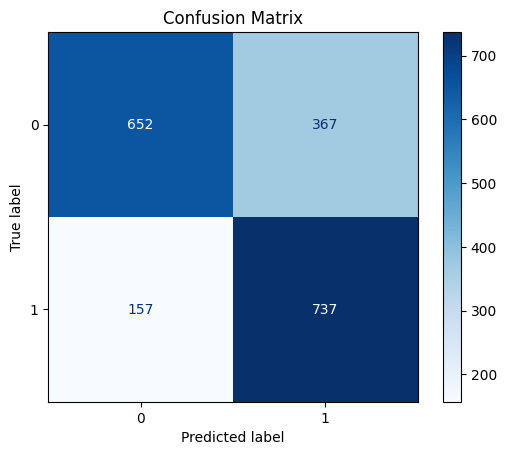

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = SVC(kernel='rbf', C=1.0, gamma='scale')

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test,y_pred))


from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
print("Cross-validation scores:", scores)
print("Mean accuracy:", scores.mean())

# Plot the confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()

              precision    recall  f1-score   support

           0       0.77      0.74      0.76      1019
           1       0.72      0.76      0.74       894

    accuracy                           0.75      1913
   macro avg       0.75      0.75      0.75      1913
weighted avg       0.75      0.75      0.75      1913

Accuracy: 0.7469942498693152
Cross-validation scores: [0.75535808 0.77365395 0.71144799 0.73810768 0.67573222]
Mean accuracy: 0.7308599824587112


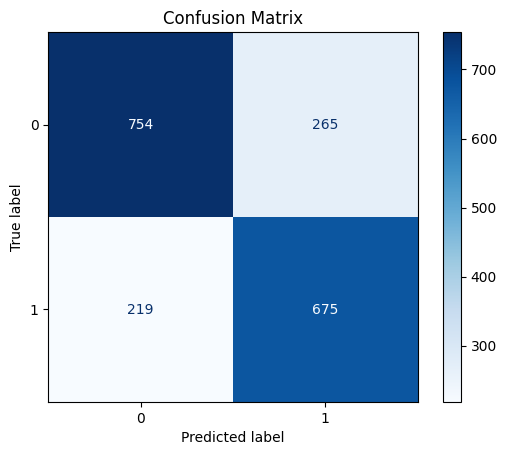

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(random_state=0)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test,y_pred))


from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
print("Cross-validation scores:", scores)
print("Mean accuracy:", scores.mean())

# Plot the confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

              precision    recall  f1-score   support

           0       0.75      0.68      0.71      1019
           1       0.67      0.75      0.71       894

    accuracy                           0.71      1913
   macro avg       0.71      0.71      0.71      1913
weighted avg       0.72      0.71      0.71      1913

Accuracy: 0.7109252483010977
Cross-validation scores: [0.71197073 0.76685834 0.67485625 0.72190277 0.71705021]
Mean accuracy: 0.7185276581504657


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

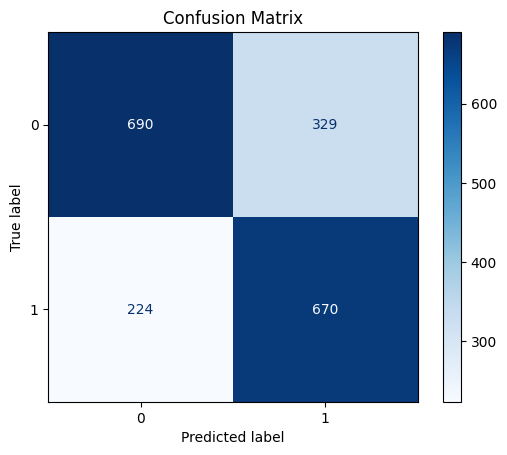

In [ ]:
from sklearn.linear_model import LogisticRegression
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(random_state=0)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test,y_pred))


from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
print("Cross-validation scores:", scores)
print("Mean accuracy:", scores.mean())

# Plot the confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()

# hyperparameter tuning






In [ ]:
rf = RandomForestClassifier(random_state=42)
param_grid = {
    "n_estimators": [50, 100, 200, 300]
}
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    verbose=2
)
grid_search.fit(X_train, y_train)
print("Best parameter:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best parameter: {'n_estimators': 100}
Best cross-validation accuracy: 0.8306106052261967


In [ ]:
rf = RandomForestClassifier(random_state=42)
param_grid = {
    "min_samples_split": [2, 5, 10, 20 ]
}
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    verbose=2
)
grid_search.fit(X_train, y_train)
print("Best parameter:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best parameter: {'min_samples_split': 2}
Best cross-validation accuracy: 0.8306106052261967


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", RidgeClassifier(random_state=42))
])
param_grid = {
    "ridge__alpha": [0.01, 0.1, 1, 10]
}
grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    verbose=2
)
grid_search.fit(X_train, y_train)
print("Best alpha:", grid_search.best_params_["ridge__alpha"])
print("Best cross-validation accuracy:", grid_search.best_score_)


Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best alpha: 0.01
Best cross-validation accuracy: 0.6710241074439791
